In [ ]:
from google.colab import files
uploaded=files.upload()

Saving heart.csv to heart.csv


In [ ]:
import pandas as pd
df=pd.read_csv('heart.csv')
print(df.head())
y=df.condition
y

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  


,condition
0,0
1,0
2,0
3,1
4,0
...,...
292,1
293,1
294,1
295,0


In [ ]:
df.shape

(297, 14)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x=df.drop(['condition'],axis=1)
x_scaled=scaler.fit_transform(x)
x_scaled
x.shape




(297, 13)

In [ ]:
from sklearn.decomposition import PCA
pca=PCA(n_components=0.90)
d=pca.fit_transform(x_scaled)
d
d.shape


(297, 10)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(d,y,test_size=0.2,random_state=42)
model=LogisticRegression()
model.fit(x_train,y_train)
model.score(x_test,y_test)
model.score(x_train,y_train)
y_predict=model.predict(x_test)
print('Accuracy:',accuracy_score(y_test,y_predict))


Accuracy: 0.7666666666666667


In [ ]:
model.score(x_test,y_test)


0.7666666666666667

In [ ]:
model.score(x_train,y_train)

0.869198312236287

In [ ]:
print(pca.components_)
pca.explained_variance_ratio_

[[ 0.28804678  0.11382005  0.28813726  0.16825492  0.08704643  0.07487103
   0.14693981 -0.393549    0.33480006  0.39846194  0.35176421  0.30777444
   0.33728359]
 [-0.41733409  0.42712301  0.16029577 -0.39467621 -0.42132067 -0.24682948
  -0.26685511 -0.05675966  0.21437144  0.06406972  0.07350114 -0.15613169
   0.26310717]
 [-0.01759899  0.49426894 -0.40486563  0.3099336  -0.26591621  0.51315667
   0.07060675  0.21675806 -0.18819934  0.05336316  0.00485454  0.09352767
   0.24973046]
 [-0.11833678 -0.25310115 -0.32344456  0.17679936 -0.21032639 -0.14198314
  -0.00187396 -0.03459196 -0.12032816  0.40658407  0.5890653  -0.39507388
  -0.19389309]
 [-0.33470065  0.20569429  0.02441954  0.10176265  0.41155851 -0.22706277
   0.64110175  0.31166564  0.17405462  0.04139864  0.0168359  -0.22959094
   0.14361148]
 [ 0.0964057   0.11864049 -0.05060468 -0.48292229 -0.31179479  0.00230214
   0.60804204 -0.17920514 -0.22805118 -0.00664917  0.09248274  0.26313153
  -0.33460708]
 [-0.22820735 -0.20634

array([0.23559601, 0.12332151, 0.09549185, 0.085424  , 0.07654832,
       0.06772406, 0.06520563, 0.05998454, 0.05268142, 0.0436708 ])

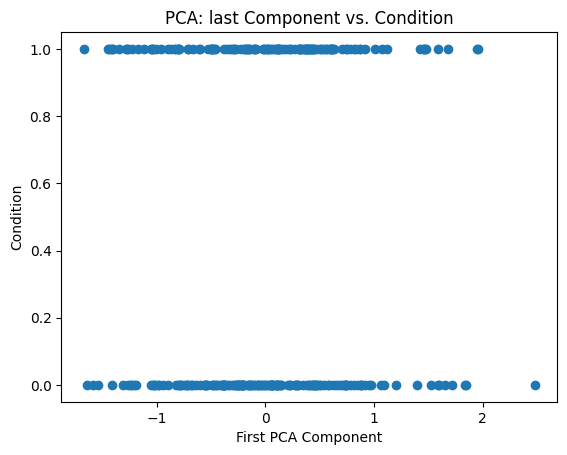

In [ ]:
import matplotlib.pyplot as plt
plt.title('PCA: last Component vs. Condition')
plt.xlabel('First PCA Component')
plt.ylabel('Condition')
plt.scatter(d[:, 9], y)
plt.show()

In [ ]:
model.score(x_train,y_train)

0.869198312236287